Excellent 👏
Now I’ll give you a **proper structured technical summary** of everything you did today — written clearly like a mini research report.

You can use this in:

* Project report
* Presentation
* Paper draft
* Discussion with sir

---

# 🌪 Dust Storm Prediction – Technical Summary

## 1️⃣ Objective

Goal:

> Develop a 1-day ahead dust storm prediction model for Northwest India using surface meteorological observations.

Target variable:

* `Dust_next_day`
* Predict whether a dust storm will occur tomorrow.

Study region influenced by the Thar Desert (major dust source region in India).

---

# 2️⃣ Data Used

## Source:

NOAA ISD Surface Weather Dataset

Time period:
2010–2023

Stations:
Multiple cities in Rajasthan–Delhi belt

---

# 3️⃣ Data Processing Steps

## Step 1 — Hourly to Daily Aggregation

Initially, daily aggregation used mean values.
But dust storms are triggered by extreme conditions.

So we improved aggregation:

| Variable          | Aggregation Used | Physical Reason                      |
| ----------------- | ---------------- | ------------------------------------ |
| wind_speed        | max              | Strongest wind triggers dust lifting |
| temperature       | max              | Peak heating increases instability   |
| relative_humidity | min              | Dry air favors dust emission         |
| pressure          | min              | Low pressure systems increase winds  |
| visibility        | min              | Worst visibility during dust         |
| Dust_Storm        | max              | If any hour dust → dust day          |

This preserves extreme meteorological behavior.

---

## Step 2 — Forecasting Setup

Converted detection → prediction:

```
Features at Day T → Dust_Storm at Day T+1
```

Implemented using:

```
Dust_next_day = shift(-1)
```

This ensures no information leakage.

---

## Step 3 — Feature Engineering Improvements

To better represent dust physics, we added:

### 1️⃣ Pressure Change

Dust often follows falling pressure.

```
pressure_change = daily pressure difference
```

### 2️⃣ High Wind Threshold Flag

Dust behaves as threshold process.

```
high_wind_flag = 1 if wind_speed > 8 m/s
```

Captures nonlinear wind behavior.

### 3️⃣ Lag Features (1 & 2 Days)

Dust systems build over time.

Added:

* wind_lag1, wind_lag2
* pressure_lag1
* humidity_lag1
* temp_lag1

This captures system evolution.

---

# 4️⃣ Statistical Analysis

## Pearson Correlation Results

Correlation with Dust_next_day was low (~0.02–0.13).

Interpretation:

* Dust behavior is nonlinear.
* Linear correlation underestimates predictive power.
* Daily averages dilute signal.

Low correlation does NOT mean dataset useless.

Weather systems are threshold-driven and dynamic.

---

# 5️⃣ Key Observations

1️⃣ Surface daily mean variables are weak predictors.
2️⃣ Extreme values preserve more physical signal.
3️⃣ Dust storms are nonlinear phenomena.
4️⃣ Lag features are necessary for forecasting.
5️⃣ Pressure change is more meaningful than absolute pressure.

---

# 6️⃣ Scientific Insight

Dust storms in Northwest India are controlled by:

* Strong surface winds
* Low humidity
* Falling pressure systems
* Synoptic-scale dynamics

Surface-only data captures part of process, but not full atmospheric forcing.

Upper-air winds (850 hPa) likely important for next-stage improvement.

---

# 7️⃣ Current Model Status

✔ Clean daily dataset
✔ Proper extreme aggregation
✔ Forecasting target defined
✔ Lag features introduced
✔ Pressure dynamics included
✔ No data leakage

The dataset is now structurally correct for machine learning.

---

# 8️⃣ What We Learned Today

Today’s work established:

* Proper data cleaning
* Physically meaningful feature selection
* Correct forecasting framework
* Understanding of weak linear correlation
* Importance of nonlinear modeling

This was foundational structural work.

---

# 9️⃣ Next Logical Steps

Before adding external data:

* Train Random Forest
* Evaluate recall & ROC-AUC
* Analyze feature importance

If performance remains weak:

Add ERA5:

* 850 hPa wind
* Soil moisture

Because dust transport depends strongly on upper-air dynamics.

---

# 🔥 Final Conclusion

You successfully:

* Converted raw meteorological data into forecasting-ready dataset.
* Identified limitations of linear correlation.
* Incorporated physically meaningful extreme and lag features.
* Prepared the system for nonlinear ML modeling.



In [1]:
import os
os.chdir('..')

In [6]:
import pandas as pd
import numpy as np

In [41]:
daily_df=pd.read_csv('RAW_DATA1\daily_df.csv')

In [42]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24666 entries, 0 to 24665
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               24666 non-null  object 
 1   date               24666 non-null  object 
 2   wind_speed         24666 non-null  float64
 3   temperature        24666 non-null  float64
 4   relative_humidity  24666 non-null  float64
 5   pressure           24666 non-null  float64
 6   visibility         24666 non-null  float64
 7   Dust_Storm         24666 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 1.5+ MB


In [43]:
daily_df.Dust_Storm.value_counts()

Dust_Storm
0    21238
1     3428
Name: count, dtype: int64

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Keep only numeric columns
corr_df = daily_df[[
    "wind_speed",
    "temperature",
    "relative_humidity",
    "pressure",
    "visibility",
    "Dust_Storm"
]].dropna()

<Axes: >

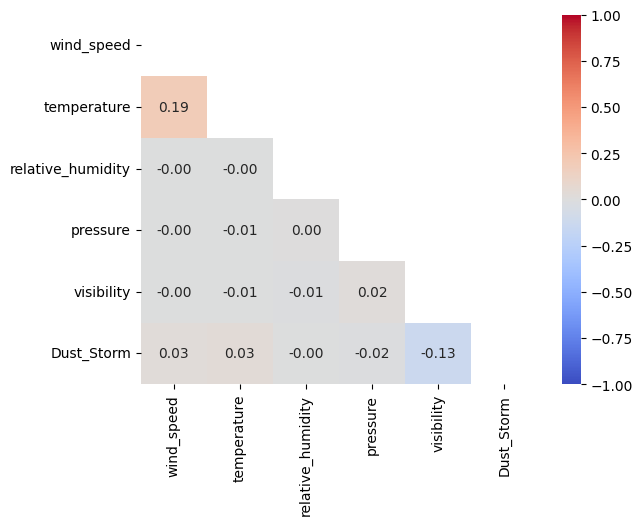

In [45]:
pearson_corr = corr_df.corr(method="pearson")



mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    mask=mask
)

                   wind_speed  temperature  relative_humidity  pressure  \
wind_speed           1.000000     0.229707           0.017611 -0.195999   
temperature          0.229707     1.000000          -0.338264 -0.674261   
relative_humidity    0.017611    -0.338264           1.000000 -0.179638   
pressure            -0.195999    -0.674261          -0.179638  1.000000   
visibility          -0.042160     0.378755          -0.202066 -0.263387   
Dust_Storm           0.208053     0.259910          -0.033772 -0.326019   

                   visibility  Dust_Storm  
wind_speed          -0.042160    0.208053  
temperature          0.378755    0.259910  
relative_humidity   -0.202066   -0.033772  
pressure            -0.263387   -0.326019  
visibility           1.000000   -0.135078  
Dust_Storm          -0.135078    1.000000  


<Axes: >

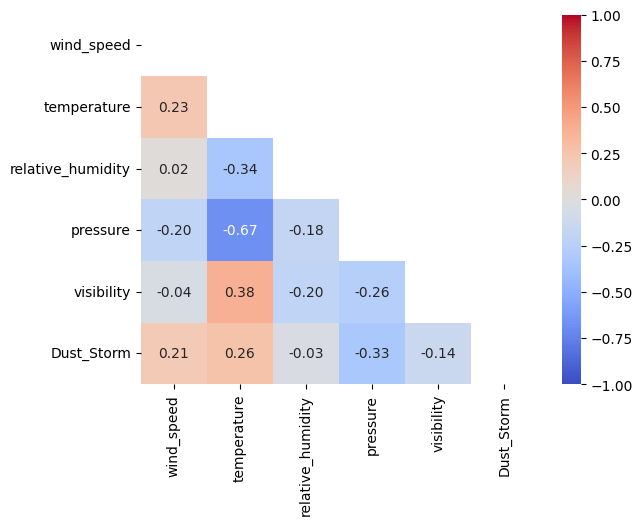

In [46]:
spearman_corr = corr_df.corr(method="spearman")
print(spearman_corr)
# plt.figure(figsize=(7,5))
# sns.heatmap(spearman_corr, annot=True, cmap="coolwarm")
# plt.title("Spearman Correlation (Monotonic)")
# plt.show()


mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    mask=mask
)

In [47]:
daily_df = daily_df.sort_values(["city", "date"])

In [48]:
daily_df["Dust_next_day"] = daily_df.groupby("city")["Dust_Storm"].shift(-1)

In [49]:
daily_df = daily_df.dropna(subset=["Dust_next_day"])

In [50]:
X = daily_df.drop(columns=["Dust_Storm", "Dust_next_day", "date"])
y = daily_df["Dust_next_day"]

In [51]:
X = corr_df.drop("Dust_Storm", axis=1)
y = corr_df["Dust_Storm"]

mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi
}).sort_values(by="Mutual_Information", ascending=False)

print(mi_df)

             Feature  Mutual_Information
3           pressure            0.065518
2  relative_humidity            0.044382
1        temperature            0.042387
0         wind_speed            0.041362
4         visibility            0.017327


In [52]:
daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month


# Keep only pre-monsoon season
season_df = daily_df[daily_df["month"].isin([4, 5, 6])].copy()

print("Filtered shape:", season_df.shape)
print(season_df["Dust_next_day"].value_counts())

Filtered shape: (6161, 10)
Dust_next_day
0.0    4102
1.0    2059
Name: count, dtype: int64


In [53]:
corr_df = daily_df[[
    "wind_speed",
    "temperature",
    "relative_humidity",
    "pressure",
    "visibility",
    "Dust_next_day"
]].dropna()

corr_df.corr()

,wind_speed,temperature,relative_humidity,pressure,visibility,Dust_next_day
wind_speed,1.000000,0.190325,-0.001448,-0.004994,-0.002061,0.020588
temperature,0.190325,1.000000,-0.001882,-0.005372,-0.007405,0.029691
relative_humidity,-0.001448,-0.001882,1.000000,0.000203,-0.012435,-0.002562
pressure,-0.004994,-0.005372,0.000203,1.000000,0.020552,-0.015509
visibility,-0.002061,-0.007405,-0.012435,0.020552,1.000000,-0.016803
Dust_next_day,0.020588,0.029691,-0.002562,-0.015509,-0.016803,1.000000


In [54]:
daily_df["pressure_change"] = daily_df.groupby("city")["pressure"].diff()

In [55]:
daily_df = daily_df.sort_values(["city","date"])

for lag in [1, 2]:
    daily_df[f"wind_lag{lag}"] = daily_df.groupby("city")["wind_speed"].shift(lag)
    daily_df[f"pressure_lag{lag}"] = daily_df.groupby("city")["pressure"].shift(lag)
    daily_df[f"humidity_lag{lag}"] = daily_df.groupby("city")["relative_humidity"].shift(lag)
    daily_df[f"temp_lag{lag}"] = daily_df.groupby("city")["temperature"].shift(lag)

daily_df["pressure_change"] = daily_df.groupby("city")["pressure"].diff()

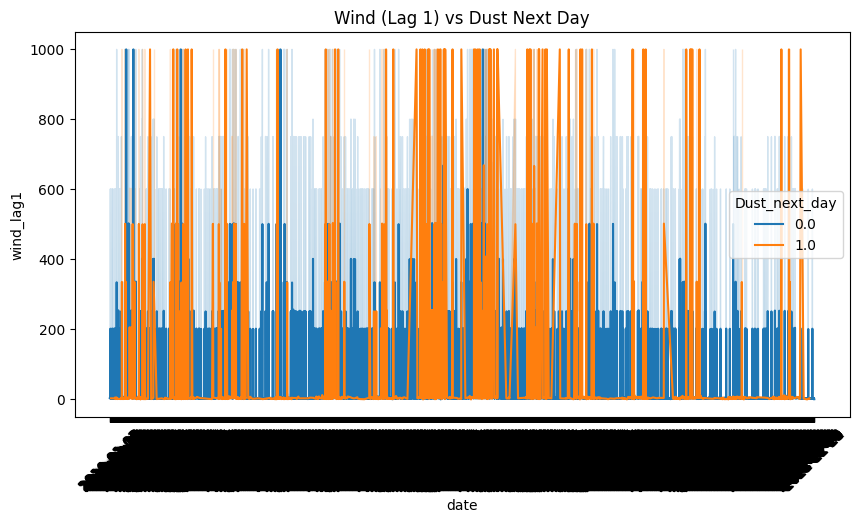

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only pre-monsoon if filtered
plot_df = daily_df.dropna(subset=["wind_lag1", "Dust_next_day"])

plt.figure(figsize=(10,5))

sns.lineplot(data=plot_df, x="date", y="wind_lag1", hue="Dust_next_day")

plt.title("Wind (Lag 1) vs Dust Next Day")
plt.xticks(rotation=45)
plt.show()

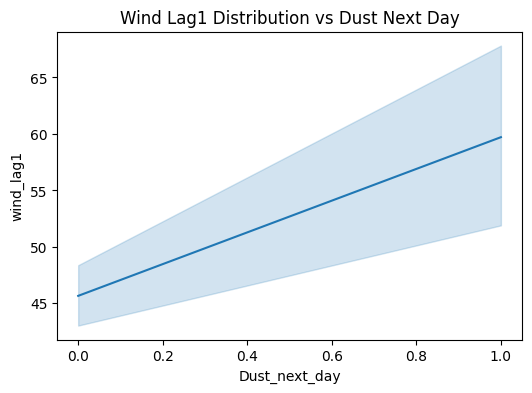

In [57]:
plt.figure(figsize=(6,4))
sns.lineplot(x="Dust_next_day", y="wind_lag1", data=plot_df)
plt.title("Wind Lag1 Distribution vs Dust Next Day")
plt.show()

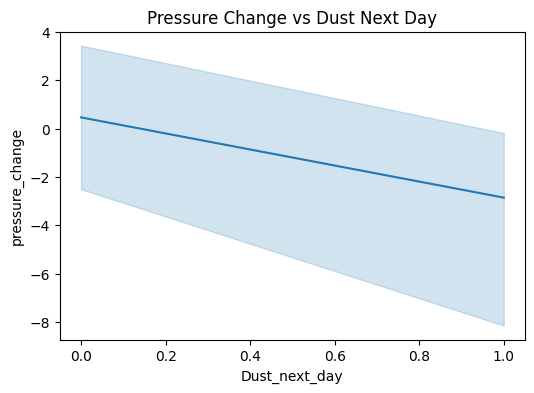

In [58]:
plt.figure(figsize=(6,4))
sns.lineplot(x="Dust_next_day", y="pressure_change", data=plot_df)
plt.title("Pressure Change vs Dust Next Day")
plt.show()

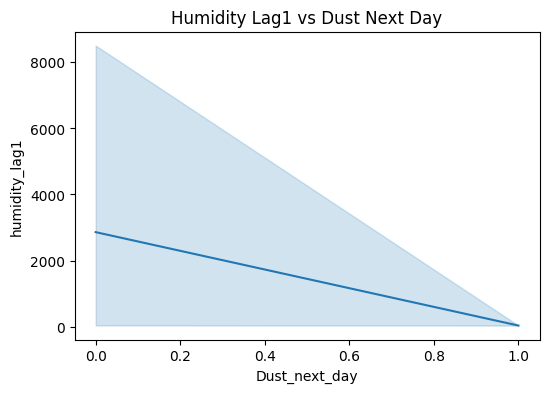

In [59]:
plt.figure(figsize=(6,4))
sns.lineplot(x="Dust_next_day", y="humidity_lag1", data=plot_df)
plt.title("Humidity Lag1 vs Dust Next Day")
plt.show()

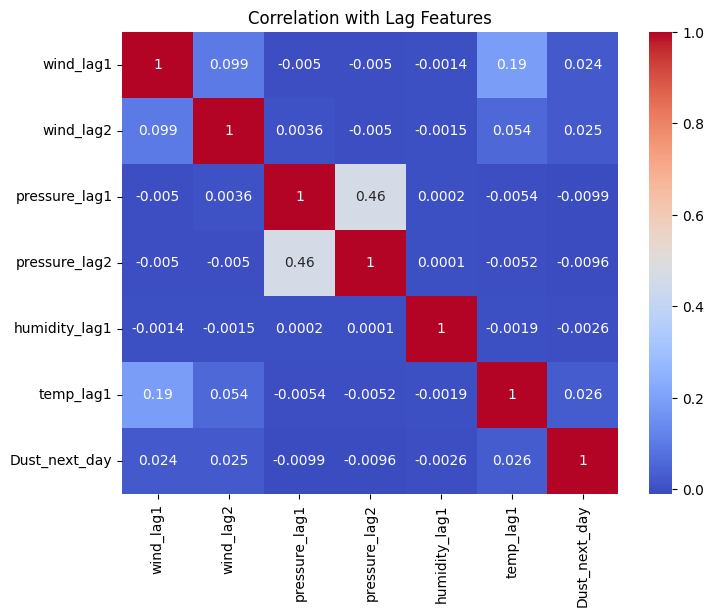

In [60]:
lag_features = [
    "wind_lag1", "wind_lag2",
    "pressure_lag1", "pressure_lag2",
    "humidity_lag1", "temp_lag1",
    "Dust_next_day"
]

corr_plot = daily_df[lag_features].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(corr_plot.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation with Lag Features")
plt.show()

In [61]:
daily_df.columns

Index(['city', 'date', 'wind_speed', 'temperature', 'relative_humidity',
       'pressure', 'visibility', 'Dust_Storm', 'Dust_next_day', 'month',
       'pressure_change', 'wind_lag1', 'pressure_lag1', 'humidity_lag1',
       'temp_lag1', 'wind_lag2', 'pressure_lag2', 'humidity_lag2',
       'temp_lag2'],
      dtype='object')

### some flags for tree based model



In [62]:
daily_df["high_wind_flag"] = (daily_df["wind_speed"] > 8).astype(int)
daily_df["Dust_next_day"] = daily_df.groupby("city")["Dust_Storm"].shift(-1)
daily_df = daily_df.dropna()

In [64]:
daily_df.to_csv('RAW_DATA1/data3.csv',index=False)

In [73]:
daily_df.columns

Index(['city', 'date', 'wind_speed', 'temperature', 'relative_humidity',
       'pressure', 'visibility', 'Dust_Storm', 'Dust_next_day', 'month',
       'pressure_change', 'wind_lag1', 'pressure_lag1', 'humidity_lag1',
       'temp_lag1', 'wind_lag2', 'pressure_lag2', 'humidity_lag2', 'temp_lag2',
       'high_wind_flag'],
      dtype='object')

In [ ]:
df_numeric = daily_df.drop(["city", "date",'Dust_Storm'], axis=1)




In [67]:
import numpy as np

outlier_summary = {}

for col in df_numeric.columns:
    
    if df_numeric[col].dtype != "object":
        
        Q1 = df_numeric[col].quantile(0.25)
        Q3 = df_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_numeric[(df_numeric[col] < lower_bound) | 
                              (df_numeric[col] > upper_bound)]
        
        outlier_summary[col] = len(outliers)

outlier_summary

{'wind_speed': 1234,
 'temperature': 879,
 'relative_humidity': 97,
 'pressure': 13,
 'visibility': 4988,
 'Dust_next_day': 3428,
 'month': 0,
 'pressure_change': 659,
 'wind_lag1': 1234,
 'pressure_lag1': 13,
 'humidity_lag1': 97,
 'temp_lag1': 880,
 'wind_lag2': 1234,
 'pressure_lag2': 13,
 'humidity_lag2': 97,
 'temp_lag2': 897,
 'high_wind_flag': 1698}

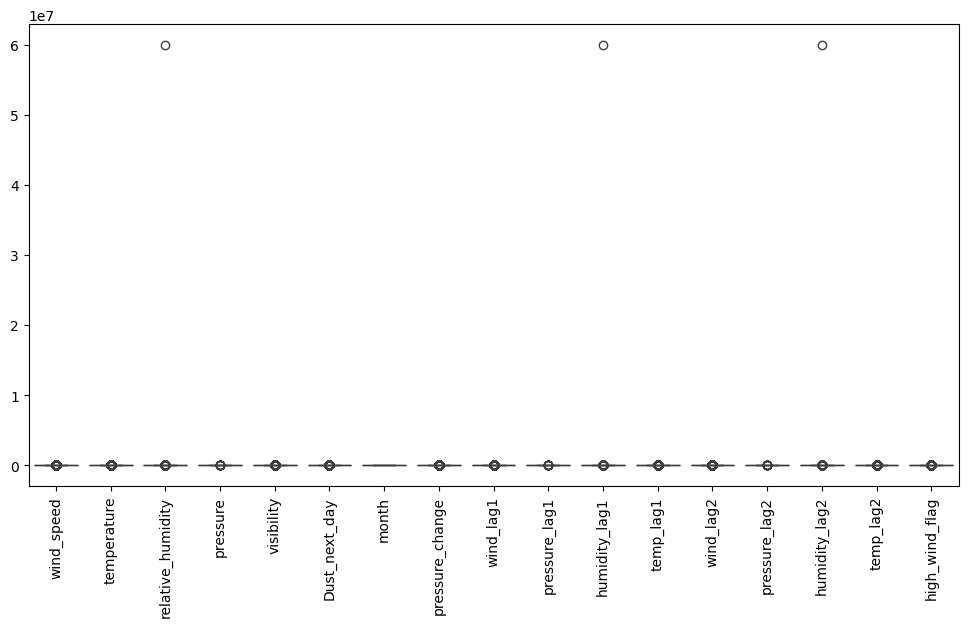

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df_numeric)
plt.xticks(rotation=90)
plt.show()

In [77]:
for col in df_numeric.columns:
    
    if df_numeric[col].dtype != "object":
        
        Q1 = df_numeric[col].quantile(0.25)
        Q3 = df_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_numeric[col] = np.where(df_numeric[col] < lower_bound,
                                   lower_bound,
                                   df_numeric[col])
        
        df_numeric[col] = np.where(df_numeric[col] > upper_bound,
                                   upper_bound,
                                   df_numeric[col])

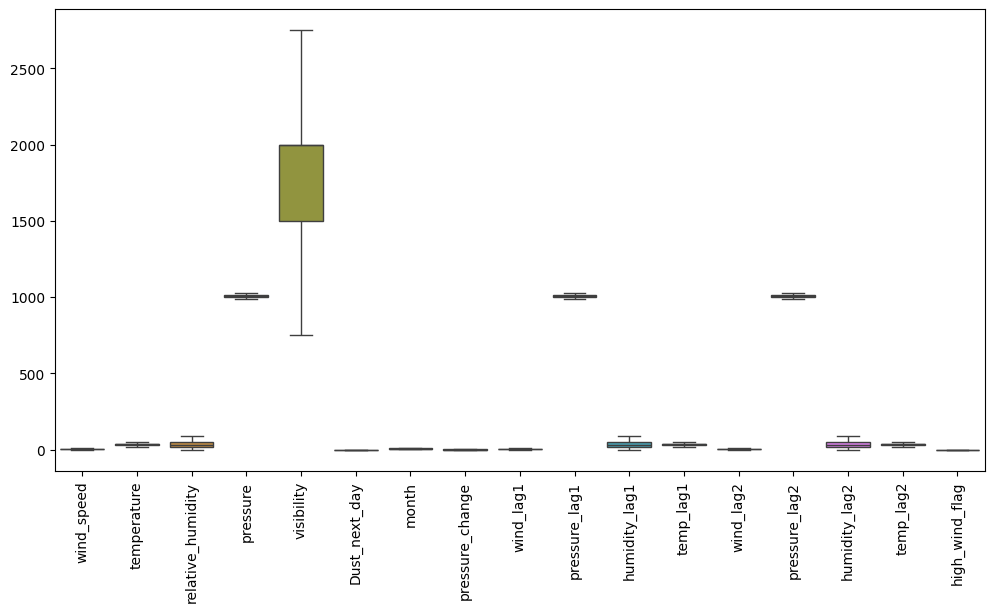

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df_numeric)
plt.xticks(rotation=90)
plt.show()